In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [23]:
roll = "102303183"

digits = [int(d) for d in roll]

window_size = sum(digits) % 10 + 8
prediction_horizon = int(roll[-2:]) % 3 + 1
hidden_size = int(roll[:3]) % 16 + 8

print(window_size, prediction_horizon, hidden_size)

9 3 14


In [24]:
data = np.sin(np.arange(0, 100, 0.1))

In [25]:
def create_windows(data, window_size, horizon):
    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)

In [26]:
X, y = create_windows(data, window_size, prediction_horizon)

In [27]:
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, horizon):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wx = nn.Linear(input_size, hidden_size)
        self.Wh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        batch_size, seq_len = x.size()
        h = torch.zeros(batch_size, self.hidden_size)

        for t in range(seq_len):
            xt = x[:, t].unsqueeze(1)
            h = torch.tanh(self.Wx(xt) + self.Wh(h))

        return self.fc(h)

In [28]:
def train(model, X, y, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y)

    for epoch in range(epochs):
        model.train()
        pred = model(X_tensor)
        loss = loss_fn(pred, y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch}: {loss.item()}")

In [29]:
model = CustomRNN(input_size=1, hidden_size=hidden_size, horizon=prediction_horizon)
train(model, X, y)

Epoch 0: 0.8068246245384216
Epoch 1: 0.7875325679779053
Epoch 2: 0.7687456607818604
Epoch 3: 0.7504607439041138
Epoch 4: 0.732673168182373
Epoch 5: 0.7153753042221069
Epoch 6: 0.6985578536987305
Epoch 7: 0.6822088360786438
Epoch 8: 0.6663138270378113
Epoch 9: 0.6508569121360779
Epoch 10: 0.6358222365379333
Epoch 11: 0.6211939454078674
Epoch 12: 0.6069561243057251
Epoch 13: 0.5930929780006409
Epoch 14: 0.5795884728431702
Epoch 15: 0.5664265155792236
Epoch 16: 0.5535907745361328
Epoch 17: 0.5410653352737427
Epoch 18: 0.5288339257240295
Epoch 19: 0.5168811082839966


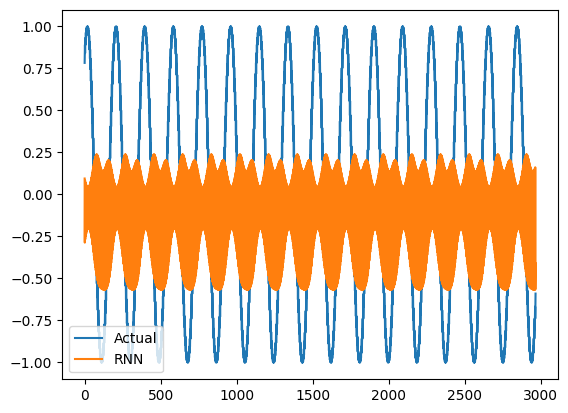

In [30]:
model.eval()

with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="RNN")
plt.legend()
plt.show()

In [61]:
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

MSE: 0.4253902708524752
MAE: 0.5800058751793671
RMSE: 0.6522194959156582


In [31]:
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(mse, mae, rmse)

0.5051920878312255 0.6178032605415138 0.7107686598544041


In [32]:
import torch.nn as nn

In [33]:
class MLP(nn.Module):
    def __init__(self, window_size, hidden_size, horizon):
        super().__init__()
        self.fc1 = nn.Linear(window_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

Epoch 0: 0.525826096534729
Epoch 1: 0.5184410810470581
Epoch 2: 0.5110441446304321
Epoch 3: 0.5036566257476807
Epoch 4: 0.496294766664505
Epoch 5: 0.4889681339263916
Epoch 6: 0.48168888688087463
Epoch 7: 0.4744724929332733
Epoch 8: 0.4673357605934143
Epoch 9: 0.4602962136268616
Epoch 10: 0.4534130096435547
Epoch 11: 0.446641206741333
Epoch 12: 0.4399031400680542
Epoch 13: 0.43320050835609436
Epoch 14: 0.4265406131744385
Epoch 15: 0.41992297768592834
Epoch 16: 0.4133489727973938
Epoch 17: 0.4068189263343811
Epoch 18: 0.40033620595932007
Epoch 19: 0.39390015602111816
MLP Metrics:
MSE: 0.3875153281234925
MAE: 0.5568639491198332
RMSE: 0.6225072916227508


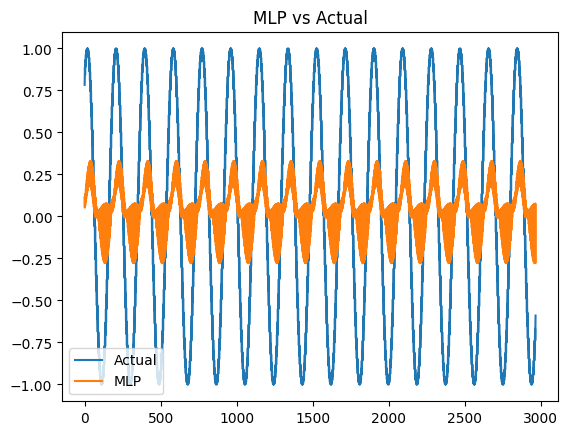

In [34]:
model = MLP(window_size, hidden_size, prediction_horizon)
train(model, X, y)

model.eval()
with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

print("MLP Metrics:")
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="MLP")
plt.legend()
plt.title("MLP vs Actual")
plt.show()

In [62]:
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

MSE: 0.4253902708524752
MAE: 0.5800058751793671
RMSE: 0.6522194959156582


MLP Metrics:
MSE: 0.3875153281234925
MAE: 0.5568639491198332
RMSE: 0.6225072916227508


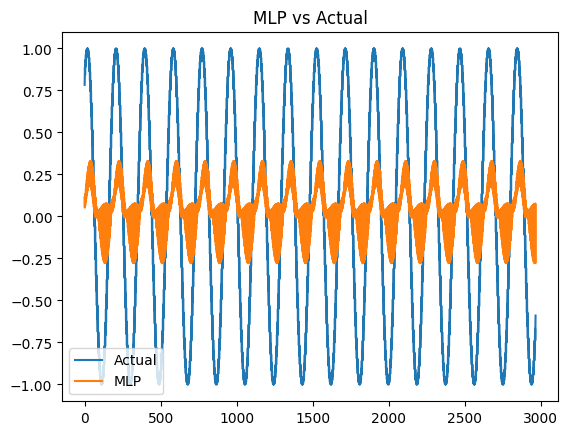

In [35]:
model.eval()

with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("MLP Metrics:")
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

import matplotlib.pyplot as plt
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="MLP")
plt.legend()
plt.title("MLP vs Actual")
plt.show()

In [36]:
class LSTMModel(nn.Module):
    def __init__(self, hidden_size, horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [37]:
model = LSTMModel(hidden_size, prediction_horizon)
train(model, X, y)

model.eval()
with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

print("LSTM Metrics:")
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Epoch 0: 0.5117897987365723
Epoch 1: 0.5092800855636597
Epoch 2: 0.5067850947380066
Epoch 3: 0.5043036937713623
Epoch 4: 0.5018351674079895
Epoch 5: 0.4993787407875061
Epoch 6: 0.49693313241004944
Epoch 7: 0.4944966733455658
Epoch 8: 0.4920671284198761
Epoch 9: 0.48964208364486694
Epoch 10: 0.48721903562545776
Epoch 11: 0.4847956895828247
Epoch 12: 0.4823698401451111
Epoch 13: 0.4799393117427826
Epoch 14: 0.47750210762023926
Epoch 15: 0.4750562310218811
Epoch 16: 0.4725993871688843
Epoch 17: 0.4701294004917145
Epoch 18: 0.46764424443244934
Epoch 19: 0.4651413857936859
LSTM Metrics:
MSE: 0.46261851036441404
MAE: 0.6109693652981836
RMSE: 0.6801606504087208


In [38]:
class TransformerModel(nn.Module):
    def __init__(self, hidden_size, horizon):
        super().__init__()
        self.input_fc = nn.Linear(1, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.input_fc(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

In [39]:
model = TransformerModel(hidden_size, prediction_horizon)
train(model, X, y)

/tmp/ipykernel_5809/1452100301.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


Epoch 0: 0.655292272567749
Epoch 1: 0.38238173723220825
Epoch 2: 0.2658049166202545
Epoch 3: 0.17476637661457062
Epoch 4: 0.1261010766029358
Epoch 5: 0.10528001934289932
Epoch 6: 0.09061425179243088
Epoch 7: 0.07518916577100754
Epoch 8: 0.06756208091974258
Epoch 9: 0.0705835148692131
Epoch 10: 0.07056501507759094
Epoch 11: 0.07267514616250992
Epoch 12: 0.06942585855722427
Epoch 13: 0.06542351096868515
Epoch 14: 0.06377605348825455
Epoch 15: 0.06169102340936661
Epoch 16: 0.059782736003398895
Epoch 17: 0.05665864422917366
Epoch 18: 0.05694401636719704
Epoch 19: 0.05863818898797035


In [40]:
original_window = window_size

In [41]:
window_size = original_window // 2

X, y = create_windows(data, window_size, prediction_horizon)

model = CustomRNN(input_size=1, hidden_size=hidden_size, horizon=prediction_horizon)
train(model, X, y)

Epoch 0: 0.5957050919532776
Epoch 1: 0.5836966633796692
Epoch 2: 0.5719155669212341
Epoch 3: 0.560363233089447
Epoch 4: 0.5490383505821228
Epoch 5: 0.5379371047019958
Epoch 6: 0.5270550847053528
Epoch 7: 0.5163857340812683
Epoch 8: 0.5059206485748291
Epoch 9: 0.4956497550010681
Epoch 10: 0.4855624735355377
Epoch 11: 0.4756481945514679
Epoch 12: 0.4658975303173065
Epoch 13: 0.4563012421131134
Epoch 14: 0.4468514025211334
Epoch 15: 0.43754035234451294
Epoch 16: 0.4283609092235565
Epoch 17: 0.4193061888217926
Epoch 18: 0.4103694558143616
Epoch 19: 0.4015443027019501


In [42]:
window_size = original_window * 2

X, y = create_windows(data, window_size, prediction_horizon)

model = CustomRNN(input_size=1, hidden_size=hidden_size, horizon=prediction_horizon)
train(model, X, y)

Epoch 0: 0.7312139868736267
Epoch 1: 0.7127282023429871
Epoch 2: 0.6945998668670654
Epoch 3: 0.6768367290496826
Epoch 4: 0.6594400405883789
Epoch 5: 0.6424105763435364
Epoch 6: 0.6257484555244446
Epoch 7: 0.6094515323638916
Epoch 8: 0.5935141444206238
Epoch 9: 0.5779287815093994
Epoch 10: 0.562686562538147
Epoch 11: 0.5477786064147949
Epoch 12: 0.5331962704658508
Epoch 13: 0.5189308524131775
Epoch 14: 0.5049737691879272
Epoch 15: 0.4913163185119629
Epoch 16: 0.4779500365257263
Epoch 17: 0.4648663401603699
Epoch 18: 0.45205700397491455
Epoch 19: 0.43951424956321716


In [50]:

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/household_power_consumption_days.csv"


In [51]:
X, y = create_windows(data, window_size, prediction_horizon)

model = CustomRNN(input_size=1, hidden_size=hidden_size, horizon=prediction_horizon)
train(model, X, y)

Epoch 0: 0.5080469846725464
Epoch 1: 0.49594980478286743
Epoch 2: 0.48407089710235596
Epoch 3: 0.4724085032939911
Epoch 4: 0.46095314621925354
Epoch 5: 0.449694961309433
Epoch 6: 0.4386272430419922
Epoch 7: 0.42774486541748047
Epoch 8: 0.41704222559928894
Epoch 9: 0.4065128266811371
Epoch 10: 0.3961489796638489
Epoch 11: 0.3859420120716095
Epoch 12: 0.3758830726146698
Epoch 13: 0.3659631311893463
Epoch 14: 0.35617393255233765
Epoch 15: 0.34650787711143494
Epoch 16: 0.3369584381580353
Epoch 17: 0.327519953250885
Epoch 18: 0.31818780303001404
Epoch 19: 0.3089582622051239


RNN Metrics:
MSE: 0.2998286925803847
MAE: 0.47615762649464904
RMSE: 0.547566153611036


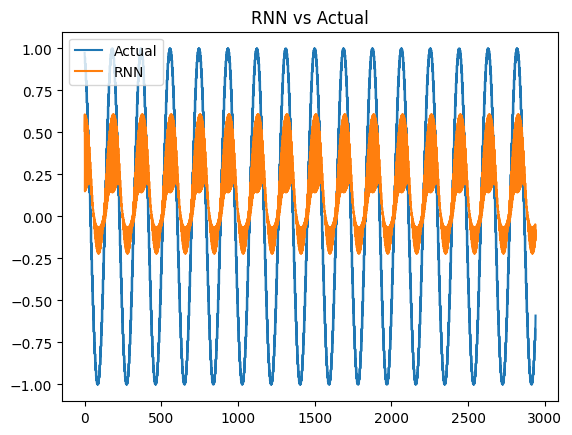

In [52]:
model.eval()
import torch

with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("RNN Metrics:")
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

import matplotlib.pyplot as plt
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="RNN")
plt.legend()
plt.title("RNN vs Actual")
plt.show()

In [63]:
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

MSE: 0.4253902708524752
MAE: 0.5800058751793671
RMSE: 0.6522194959156582


In [53]:
model = MLP(window_size, hidden_size, prediction_horizon)
train(model, X, y)

model.eval()
with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

print("MLP Metrics:")
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Epoch 0: 0.6005228757858276
Epoch 1: 0.5933655500411987
Epoch 2: 0.5863174200057983
Epoch 3: 0.5793818831443787
Epoch 4: 0.572559118270874
Epoch 5: 0.5658477544784546
Epoch 6: 0.5592431426048279
Epoch 7: 0.5527513027191162
Epoch 8: 0.5463897585868835
Epoch 9: 0.5401947498321533
Epoch 10: 0.5342485904693604
Epoch 11: 0.5287861824035645
Epoch 12: 0.5236039757728577
Epoch 13: 0.5184935927391052
Epoch 14: 0.5134382843971252
Epoch 15: 0.5084367394447327
Epoch 16: 0.5034835934638977
Epoch 17: 0.4985720217227936
Epoch 18: 0.4936996400356293
Epoch 19: 0.48886147141456604
MLP Metrics:
MSE: 0.4840585126233605
MAE: 0.6126930736104322
RMSE: 0.6957431369574266


In [54]:
model = LSTMModel(hidden_size, prediction_horizon)
train(model, X, y)

model.eval()
with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

print("LSTM Metrics:")
print("MSE:", mean_squared_error(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Epoch 0: 0.5003292560577393
Epoch 1: 0.49642208218574524
Epoch 2: 0.49254998564720154
Epoch 3: 0.48870915174484253
Epoch 4: 0.4848969876766205
Epoch 5: 0.48111212253570557
Epoch 6: 0.4773525595664978
Epoch 7: 0.4736159145832062
Epoch 8: 0.46989932656288147
Epoch 9: 0.46619898080825806
Epoch 10: 0.4625108242034912
Epoch 11: 0.4588305354118347
Epoch 12: 0.4551537036895752
Epoch 13: 0.45147618651390076
Epoch 14: 0.44779396057128906
Epoch 15: 0.4441032111644745
Epoch 16: 0.44040021300315857
Epoch 17: 0.4366811215877533
Epoch 18: 0.4329422414302826
Epoch 19: 0.4291798770427704
LSTM Metrics:
MSE: 0.4253902708524752
MAE: 0.5800058751793671
RMSE: 0.6522194959156582


In [55]:
model = TransformerModel(hidden_size, prediction_horizon)
train(model, X, y)

/tmp/ipykernel_5809/1452100301.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


Epoch 0: 0.8143078684806824
Epoch 1: 0.26181238889694214
Epoch 2: 0.18069010972976685
Epoch 3: 0.15808363258838654
Epoch 4: 0.11068477481603622
Epoch 5: 0.07788310199975967
Epoch 6: 0.0638013407588005
Epoch 7: 0.062011152505874634
Epoch 8: 0.06150221452116966
Epoch 9: 0.06339575350284576
Epoch 10: 0.06566204875707626
Epoch 11: 0.06519927084445953
Epoch 12: 0.06343407928943634
Epoch 13: 0.060212716460227966
Epoch 14: 0.058891452848911285
Epoch 15: 0.05389620363712311
Epoch 16: 0.050916992127895355
Epoch 17: 0.05099495127797127
Epoch 18: 0.048525117337703705
Epoch 19: 0.04985971748828888


In [64]:
model.eval()
with torch.no_grad():
    y_pred = model(torch.FloatTensor(X)).numpy()
    y_true = y

y_true = y_true.flatten()
y_pred = y_pred.flatten()

In [56]:
original_window = window_size

In [57]:
window_size = original_window // 2

X, y = create_windows(data, window_size, prediction_horizon)

model = CustomRNN(input_size=1, hidden_size=hidden_size, horizon=prediction_horizon)
train(model, X, y)

Epoch 0: 0.8214675188064575
Epoch 1: 0.8059763312339783
Epoch 2: 0.7907955646514893
Epoch 3: 0.7759331464767456
Epoch 4: 0.7613928914070129
Epoch 5: 0.7471776008605957
Epoch 6: 0.7332916259765625
Epoch 7: 0.7197399139404297
Epoch 8: 0.7065263390541077
Epoch 9: 0.6936537027359009
Epoch 10: 0.6811227798461914
Epoch 11: 0.6689325571060181
Epoch 12: 0.6570804119110107
Epoch 13: 0.6455620527267456
Epoch 14: 0.6343718767166138
Epoch 15: 0.6235030889511108
Epoch 16: 0.6129482984542847
Epoch 17: 0.602699339389801
Epoch 18: 0.5927473306655884
Epoch 19: 0.5830830335617065


In [58]:
window_size = original_window * 2

X, y = create_windows(data, window_size, prediction_horizon)

model = CustomRNN(input_size=1, hidden_size=hidden_size, horizon=prediction_horizon)
train(model, X, y)

Epoch 0: 0.778215765953064
Epoch 1: 0.7647966742515564
Epoch 2: 0.751614511013031
Epoch 3: 0.7386743426322937
Epoch 4: 0.7259787321090698
Epoch 5: 0.7135274410247803
Epoch 6: 0.7013188004493713
Epoch 7: 0.6893503069877625
Epoch 8: 0.6776179075241089
Epoch 9: 0.6661161780357361
Epoch 10: 0.6548385620117188
Epoch 11: 0.6437784433364868
Epoch 12: 0.6329289674758911
Epoch 13: 0.6222832202911377
Epoch 14: 0.6118342280387878
Epoch 15: 0.6015746593475342
Epoch 16: 0.5914968252182007
Epoch 17: 0.5815927386283875
Epoch 18: 0.5718542337417603
Epoch 19: 0.5622730851173401


In [60]:
print("Window size:", window_size)
print("MSE:", mean_squared_error(y_true, y_pred))

Window size: 36
MSE: 0.4253902708524752
